In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading model...
Running GPU predictions 🚀 ...

✅ Test Accuracy: 95.73%

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.98      0.99      0.98       376
           brown_spot       0.92      0.91      0.91       380
              healthy       0.98      0.95      0.96       391
           leaf_blast       0.88      0.88      0.88       362
           leaf_scald       0.99      0.99      0.99       386
    narrow_brown_spot       0.95      0.93      0.94       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       0.91      1.00      0.96       225
        sheath_blight       0.98      0.95      0.96       288
               tungro       0.99      1.00      0.99       310

             accuracy                           0.96      3422
            macro avg       0.96      0.96      0.96      3422
         weighted avg   

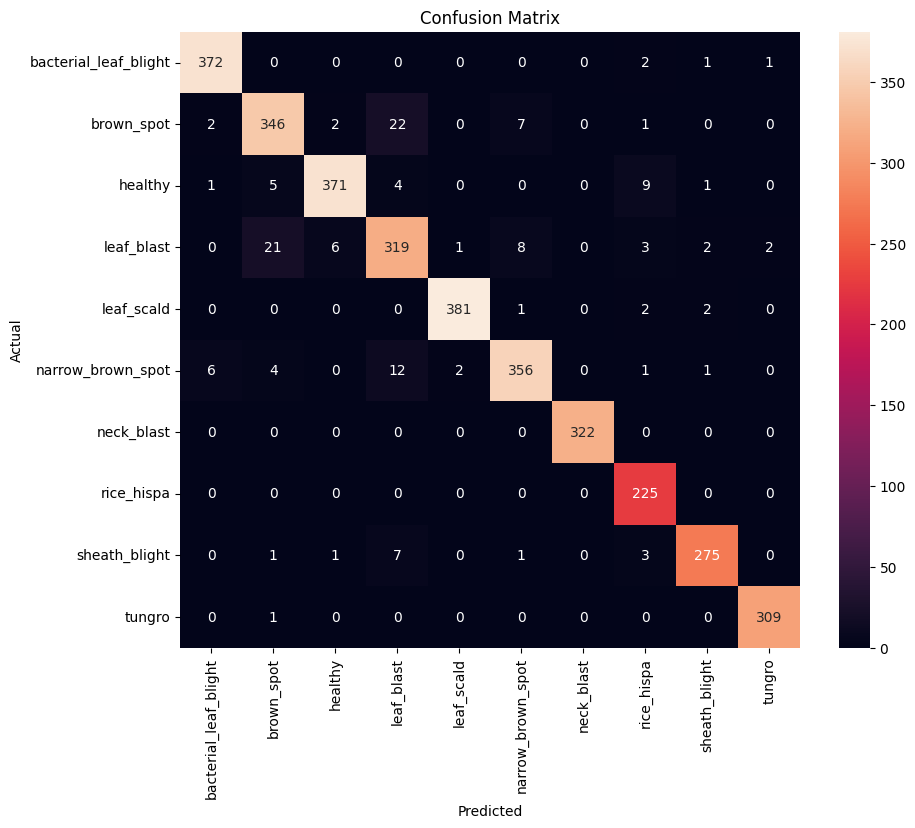

In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ✅ Confirm GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# --------------------------------------------------
# PATHS
# --------------------------------------------------
MODEL_PATH = "/content/drive/MyDrive/Datasets/rice/model_rice_disease.keras"
TEST_DIR = "/content/drive/MyDrive/Datasets/rice/test"

# --------------------------------------------------
# CLASS NAMES
# --------------------------------------------------
CLASS_NAMES = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "narrow_brown_spot",
    "neck_blast",
    "rice_hispa",
    "sheath_blight",
    "tungro"
]

CLASS_NAMES.sort()

# --------------------------------------------------
# LOAD MODEL (AUTO USES GPU)
# --------------------------------------------------
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

IMG_SIZE = 224


def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    img = tf.keras.applications.efficientnet.preprocess_input(img)

    preds = model.predict(img, verbose=0)
    return np.argmax(preds)


# --------------------------------------------------
# RUN TEST
# --------------------------------------------------
y_true = []
y_pred = []

print("Running GPU predictions 🚀 ...")

for class_index, class_name in enumerate(CLASS_NAMES):

    class_path = os.path.join(TEST_DIR, class_name)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        pred = predict_image(img_path)

        y_true.append(class_index)
        y_pred.append(pred)


# --------------------------------------------------
# METRICS
# --------------------------------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%\n")

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/Datasets/rice/confusion_matrix.png")

plt.show()